In [2]:
import pandas as pd
import numpy as np
import plotly.express as px

play = pd.read_csv("Play Store Data.csv")

In [5]:
play = play.drop_duplicates(subset="App")
play = play.reset_index(drop=True)

In [7]:
play = play[play["Category"] != "1.9"]

In [9]:
play["Rating"] = pd.to_numeric(
    play["Rating"],
    errors="coerce"
)

In [12]:
play["Reviews"] = pd.to_numeric(
    play["Reviews"],
    errors="coerce"
)

In [15]:
play["Installs"] = (
    play["Installs"]
    .astype(str)
    .str.replace(",", "")
    .str.replace("+", "")
)

play["Installs"] = pd.to_numeric(
    play["Installs"],
    errors="coerce"
)

In [17]:
play["Last Updated"] = pd.to_datetime(
    play["Last Updated"],
    errors="coerce"
)

In [19]:
play["Size"] = play["Size"].astype(str)

def convert_size(size):

    if "M" in size:
        return float(size.replace("M",""))

    elif "k" in size:
        return float(size.replace("k",""))/1024

    else:
        return np.nan

play["Size_MB"] = play["Size"].apply(convert_size)

In [21]:
df = play[
    play["Rating"] >= 4.0
]

In [23]:
df = df[
    df["Size_MB"] >= 10
]

In [26]:
df = df[
    df["Last Updated"].dt.month == 1
]

In [28]:
top10 = (
    df.groupby("Category")["Installs"]
      .sum()
      .nlargest(10)
      .index
)

In [30]:
df = df[
    df["Category"].isin(top10)
]

In [32]:
summary = (
    df.groupby("Category")
      .agg({
          "Rating":"mean",
          "Reviews":"sum"
      })
      .reset_index()
)

In [35]:
summary.columns = [
    "Category",
    "Average Rating",
    "Total Reviews"
]

In [36]:
fig = px.bar(

    summary,

    x="Category",

    y=["Average Rating","Total Reviews"],

    barmode="group",

    title="Average Rating and Total Reviews for Top 10 Categories by Installs"

)

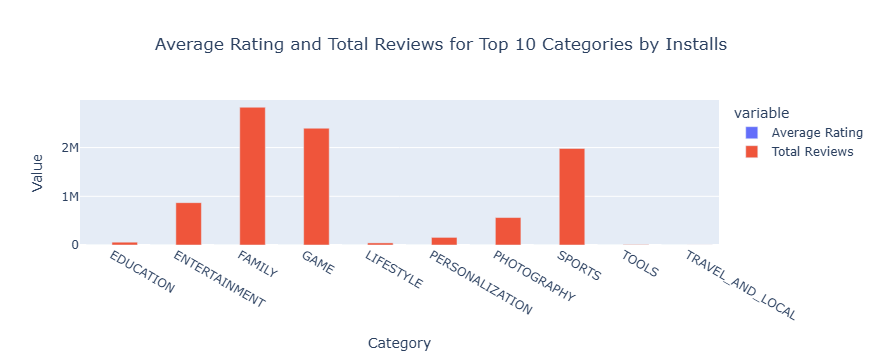

In [38]:
fig.update_layout(

    xaxis_title="Category",

    yaxis_title="Value",

    title_x=0.5

)

In [40]:
from datetime import datetime
import pytz

india = pytz.timezone("Asia/Kolkata")
now = datetime.now(india)

if 15 <= now.hour < 17:

    fig.show()

else:

    print(
        "This graph is available only between "
        "3 PM IST and 5 PM IST."
    )

This graph is available only between 3 PM IST and 5 PM IST.


In [41]:
fig.write_html(
    "grouped_bar_dashboard.html",
    include_plotlyjs="cdn"
)